# BioJEPA v0.7 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_7 import BioJepa, BioJepaConfig
from dataloader_v0_7 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v0_7 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v0_7 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

## Device & Paths

In [2]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('~/data/v0_7').expanduser()
ref_root = Path('~/data/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cuda


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer= 6,
    heads= 4,
    embed_dim= 256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=40.5,
    std_coeff=40.5,
    cov_coeff=1.62,
    pert_latent_dim=128,
    pert_mode_dim=64,
)

# Encoder training: WSD schedule with context L2 as last 5% polish + EMA annealing to 0.999
encoder_cfg = EncoderTrainingConfig(
    epochs=50, lr=1e-4, batch_size=64, phase2_start_pct=0.8,
    context_coeff=2.0, context_ramp_start_pct=0.95, context_ramp_pct=0.05,
    ema_final_momentum=0.999,
)

# Composer training: 10k epochs (matches v9 HPO horizon); update lr/wd/temperature with HPO v9 winners
composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=3.6e-4, batch_size=64, weight_decay=0.003, temperature=0.00126, chemical_fraction=0.1,
)

# AC training: composer frozen (lr_mult=0.01), predictor LR reverted to 1e-4
ac_cfg = ACTrainingConfig(
    epochs=20, predictor_lr=1e-4, batch_size=32, mask_anneal_pct=0.2, mask_anneal_floor=0.0,
    beta_nll_target=0.2, beta_nll_anneal_pct=0.4, composer_lr_mult=0.01,
)

decoder_cfg = DecoderConfig(epochs=20, lr=1e-3, batch_size=32)


## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 7,979,522
ACpredictor: 9,987,072
PerturbationComposer: 444,224


### Load pretraining model from checkpoint (for resuming)

In [5]:
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_7_ac_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path, map_location=device)

keys = model.load_state_dict(checkpoint['model'])
keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [ ]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

In [ ]:
# decompress_npz(data_cfg.data_root / 'encoder_t')

In [ ]:
# decompress_npz(data_cfg.data_root / 'predictor_t') 

## Encoder Training

In [6]:
enc_train_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device )
enc_val_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device)

found 1175 shards for split train
shard balancing (threshold=133, 20% of max=664):
  adamson: 23 -> 138 shards (x6)
  k562e_raw: 98 -> 196 shards (x2)
  k562gw: 664 shards
  norman: 39 -> 156 shards (x4)
  rep1e: 83 -> 166 shards (x2)
  sciplex: 268 shards
found 70 shards for split val


In [7]:
pt_results = run_encoder_training(model, enc_train_loader, enc_val_loader, encoder_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=2)

Encoder training: 4065280 samples, 63520 steps/epoch, 3176000 total steps
WSD schedule: warmup=158800 steps, phase2 starts at step 2540800
Context L2: target=2.0, ramp starts at step 2540800
EMA annealing: 0.995 -> 1.0 during phase 2


W0331 00:03:21.963000 71422 site-packages/torch/_inductor/scheduler.py:3820] [0/1] Layout conflict detected for buf1: template expects FixedLayout('cuda:0', torch.bfloat16, size=[640000, 1], stride=[1, 1]) but layout is frozen to FixedLayout('cuda:0', torch.bfloat16, size=[640000, 1], stride=[1, 640000])
W0331 00:03:21.978000 71422 site-packages/torch/_inductor/scheduler.py:3820] [0/1] Layout conflict detected for buf1: template expects FixedLayout('cuda:0', torch.bfloat16, size=[640000, 1], stride=[1, 1]) but layout is frozen to FixedLayout('cuda:0', torch.bfloat16, size=[640000, 1], stride=[1, 640000])
W0331 00:03:22.022000 71422 site-packages/torch/_inductor/scheduler.py:3820] [0/1] Layout conflict detected for buf1: template expects FixedLayout('cuda:0', torch.bfloat16, size=[640000, 1], stride=[1, 1]) but layout is frozen to FixedLayout('cuda:0', torch.bfloat16, size=[640000, 1], stride=[1, 640000])
W0331 00:03:22.080000 71422 site-packages/torch/_inductor/scheduler.py:3820] [0/1]

Step 0 | val loss: 95.7788
Step 0 | Loss: 96.98167 | LR: 3.15e-10 | Phase: 1
Step 100 | Loss: 95.59400 | LR: 3.18e-08 | Phase: 1
Step 200 | Loss: 94.39815 | LR: 6.33e-08 | Phase: 1
Step 300 | Loss: 94.36174 | LR: 9.48e-08 | Phase: 1
Step 400 | Loss: 95.07500 | LR: 1.26e-07 | Phase: 1
Step 500 | val loss: 90.0731
Step 500 | Loss: 90.84390 | LR: 1.58e-07 | Phase: 1
Step 600 | Loss: 87.12576 | LR: 1.89e-07 | Phase: 1
Step 700 | Loss: 83.63593 | LR: 2.21e-07 | Phase: 1
Step 800 | Loss: 80.48739 | LR: 2.52e-07 | Phase: 1
Step 900 | Loss: 78.13541 | LR: 2.84e-07 | Phase: 1
Step 1000 | val loss: 78.3391
Step 1000 | Loss: 73.16081 | LR: 3.15e-07 | Phase: 1
Step 1100 | Loss: 70.08618 | LR: 3.47e-07 | Phase: 1
Step 1200 | Loss: 67.89481 | LR: 3.78e-07 | Phase: 1
Step 1300 | Loss: 64.74977 | LR: 4.10e-07 | Phase: 1
Step 1400 | Loss: 63.86483 | LR: 4.41e-07 | Phase: 1
Step 1500 | val loss: 63.8933
Step 1500 | Loss: 62.33963 | LR: 4.73e-07 | Phase: 1
Step 1600 | Loss: 60.42401 | LR: 5.04e-07 | Phas

W0331 07:29:43.176000 71422 site-packages/torch/_inductor/scheduler.py:3820] [0/3] Layout conflict detected for buf1: template expects FixedLayout('cuda:0', torch.float32, size=[640000, 1], stride=[1, 1]) but layout is frozen to FixedLayout('cuda:0', torch.float32, size=[640000, 1], stride=[1, 640000])
W0331 07:29:43.187000 71422 site-packages/torch/_inductor/scheduler.py:3820] [0/3] Layout conflict detected for buf1: template expects FixedLayout('cuda:0', torch.float32, size=[640000, 1], stride=[1, 1]) but layout is frozen to FixedLayout('cuda:0', torch.float32, size=[640000, 1], stride=[1, 640000])
W0331 07:29:43.227000 71422 site-packages/torch/_inductor/scheduler.py:3820] [0/3] Layout conflict detected for buf1: template expects FixedLayout('cuda:0', torch.float32, size=[640000, 1], stride=[1, 1]) but layout is frozen to FixedLayout('cuda:0', torch.float32, size=[640000, 1], stride=[1, 640000])
/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/torch/_inductor/select

Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
found 67 shards for split val
found 67 shards for split val
found 67 shards for split val
found 67 shards for split val
found 67 shards for split val
Epoch 2 metrics: {'pert_auroc': 0.5358, 'eff_dim_90': 7, 'dead_dims': 0, 'recon_pearson': 0.9616, 'invariance_ratio': 0.891, 'kegg_similarity_ratio': 1.1265, 'cell_type_acc': 0.8604, 'essential_auroc': 0.6391, 'consistency_ratio': 0.7532}
Step 127100 | Loss: 45.18029 | LR: 4.00e-05 | Phase: 1
Step 127200 | Loss: 45.23700 | LR: 4.01e-05 | Phase: 1
Step 127300 | Loss: 44.04113 | LR: 4.01e-05 | Phase: 1
Step 127400 | Loss: 44.66093 | LR: 4.01e-05 | Phase: 1
Step 127500 | val loss: 46.5329
Step 127500 | Loss: 45.54729 | LR: 4.01e-05 | Phase: 1
Step 127600 | Loss: 45.49819 | LR: 4.02e-05 | Phase: 1
Step 127700 | Loss: 45.21032 | LR: 4.02e-05 | Phase: 1
Step 127800 | Loss: 45.56914 | LR: 4.02e-05 | Phase: 1
Step 127900 | Loss: 45.90831 | LR: 4.03

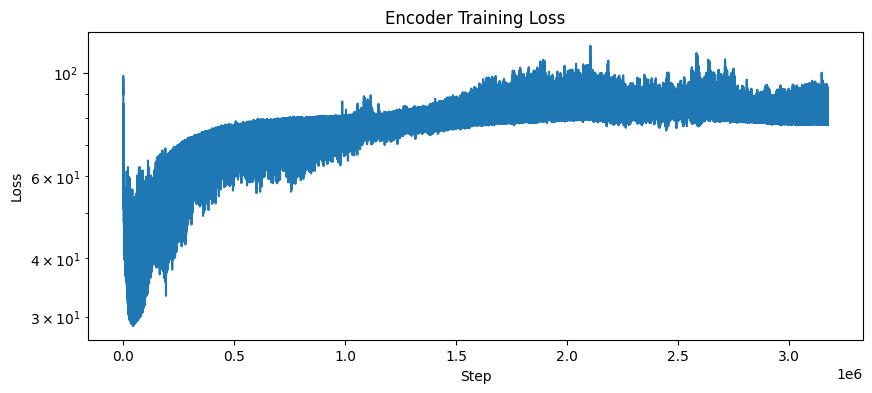

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Encoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [9]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Encoder Training Evals

In [7]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': encoder_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
pt_eval_results = run_encoder_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(pt_eval_results, data_cfg.eval_results_dir / 'encoder_eval_report.json')
pt_eval_results

Using cuda
found 135 shards for split test


batch_invariance: Extracting embeddings: 100%|███████████| 5400/5400 [06:23<00:00, 14.09it/s]


Training classifiers...
batch_invariance: Batch=0.0527 (22.8x), Pert=0.0281 (31.1x)
batch_invariance summary: global_ratio=0.533, within_dataset_macro_ratio=0.458
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
gene_embedding_pathways: KEGG ratio=1.1854
essential_gene_prediction: Pearson=0.1228, AUROC=0.5797
found 135 shards for split test


cell_type_probing: Extracting embeddings: 100%|██████████| 5400/5400 [06:19<00:00, 14.24it/s]


Training cell type classifier...
cell_type_probing: Accuracy=0.8506 (3.4x chance), Macro F1=0.5598
found 135 shards for split test


...

embedding_consistency: Extracting embeddings: 100%|██████| 5400/5400 [06:20<00:00, 14.18it/s]


embedding_consistency: Computing intra-distances for 1429 perturbations...
embedding_consistency: Computing 5000 inter-distances...
embedding_consistency: Intra=9.4788, Inter=9.9887, Ratio=1.05x
embedding_consistency: Computing for dataset adamson...
embedding_consistency: Computing for dataset k562e_raw...
embedding_consistency: Computing for dataset k562gw...
embedding_consistency: Computing for dataset norman...
embedding_consistency: Computing for dataset rep1e...
embedding_consistency: Computing for dataset sciplex...
found 135 shards for split test


latent_space_health: Extracting embeddings: 100%|████████| 5400/5400 [06:16<00:00, 14.33it/s]


latent_space_health: Eff_dim_90=12/256, Mean_var=0.2732, Isotropy=0.000001
permutation_invariance [adamson]: mean=0.482214, min=-0.563493
permutation_invariance [k562e_raw]: mean=0.455634, min=-0.812994
permutation_invariance [k562gw]: mean=0.443849, min=-0.664212
permutation_invariance [norman]: mean=0.514634, min=-0.532473
permutation_invariance [rep1e]: mean=0.439069, min=-0.644214
permutation_invariance [sciplex]: mean=0.408320, min=-0.790533
permutation_invariance overall: mean=0.458142, min=-0.812994
Saved report to /home/ubuntu/data/v0_7/eval_results/encoder_eval_report.json


{'batch_invariance': {'config': {'samples': 345600,
   'embedding_dim': 256,
   'num_batches': 432,
   'num_perturbations': 1106},
  'batch_classifier': {'accuracy': 0.052734375,
   'chance': 0.0023148148148148147,
   'above_chance_ratio': 22.78125},
  'perturbation_classifier': {'accuracy': 0.028096064814814813,
   'chance': 0.0009041591320072332,
   'above_chance_ratio': 31.074247685185185},
  'invariance_ratio': 0.5327846364883402,
  'by_dataset': {'k562e_raw': {'config': {'samples': 46506,
     'embedding_dim': 256,
     'num_batches': 48,
     'num_perturbations': 286},
    'batch_classifier': {'accuracy': 0.08116534078692754,
     'chance': 0.020833333333333332,
     'above_chance_ratio': 3.895936357772522},
    'perturbation_classifier': {'accuracy': 0.013867985379488282,
     'chance': 0.0034965034965034965,
     'above_chance_ratio': 3.966243818533649},
    'invariance_ratio': 0.17086092715231788},
   'k562gw': {'config': {'samples': 189095,
     'embedding_dim': 256,
     'nu

In [8]:
# compress_npz(data_cfg.data_root / 'encoder_t')

In [9]:
del enc_train_loader, enc_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

BioJepa(
  (student): OptimizedModule(
    (_orig_mod): CellStateEncoder(
      (expr_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_input_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_projection): GaussianFourierProjection()
      (film_generator): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=512, bias=True)
      )
      (total_count_proj): Linear(in_features=1, out_features=256, bias=True)
      (blocks): ModuleList(
        (0-5): 6 x CellStateBlock(
          (ln_1): RMSNorm()
          (attn): BioLinearAttention(
            (q_proj): Linear(in_features=256, out_features=256, bias=True)
            (k_proj): Linear(in_features=256, out_features=256, bias=True)
            (v_proj): Linear(in_features=256, out_features=256, bias=True)
            (c_proj): Linear(in_features=256, out_features=256, bias=True)

## Stage 2: Composer Training

In [10]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250,
    seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
  modality balancing: target chemical_fraction=10%
found 1 shards for split val


In [11]:
align_results = run_composer_training(model, comp_train_loader, comp_val_loader, seq_banks, target_bank, composer_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Composer training: 1250 samples, 19 steps/epoch, 2850000 total steps
InfoNCE loss (temperature: 0.00126)
Step 0 | val loss: 39.3728
Step 0 | Loss: 47.90531 | LR: 1.44e-05
Step 2500 | Loss: 3.87299 | LR: 1.47e-05
Step 5000 | Loss: 3.77464 | LR: 1.54e-05
Step 7500 | Loss: 3.58218 | LR: 1.68e-05
Step 10000 | val loss: 4.4028
Step 10000 | Loss: 3.37479 | LR: 1.86e-05
Step 12500 | Loss: 3.69593 | LR: 2.09e-05
Step 15000 | Loss: 3.22012 | LR: 2.38e-05
Step 17500 | Loss: 3.47754 | LR: 2.71e-05
Step 20000 | val loss: 4.7739
Step 20000 | Loss: 3.61451 | LR: 3.09e-05
Step 22500 | Loss: 3.24916 | LR: 3.52e-05
Step 25000 | Loss: 3.38094 | LR: 4.00e-05
Step 27500 | Loss: 3.36984 | LR: 4.52e-05
Step 30000 | val loss: 4.5685
Step 30000 | Loss: 3.66301 | LR: 5.08e-05
Step 32500 | Loss: 3.62494 | LR: 5.69e-05
Step 35000 | Loss: 3.36848 | LR: 6.33e-05
Step 37500 | Loss: 3.37269 | LR: 7.02e-05
Step 40000 | val loss: 4.4753
Step 40000 | Loss: 3.00939 | LR: 7.74e-05
Step 42500 | Loss: 3.03233 | LR: 8.49e-0

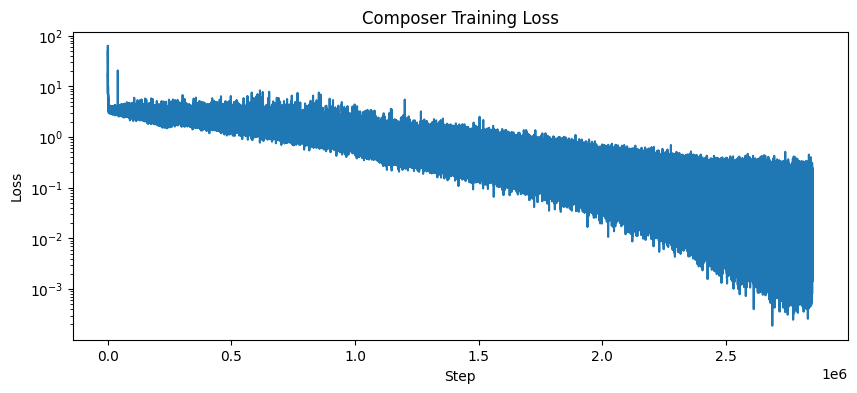

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Composer Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Composer Training Evals

In [13]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': composer_cfg.batch_size, 'seed': SEED
}
model.eval()
align_eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
align_eval_ctx._biojepa = model
align_eval_results = run_composer_evals(align_eval_ctx)
align_eval_ctx._biojepa = None

save_report(align_eval_results, data_cfg.eval_results_dir / 'composer_eval_report.json')
align_eval_results

Using cuda
Loaded 10791 v0.7 alignment pairs
Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Encoded DNA sequences: torch.Size([11643, 128])
Encoded chemical sequences: torch.Size([188, 128])
Loaded target bank: torch.Size([9975, 320])
Encoded protein targets: torch.Size([9975, 128])
seq_to_target_retrieval: dna_mrr=0.4144
cross_modality_target_consistency: Within=0.9625, Between=0.9553, Ratio=1.01x
seq_target_gap_analysis: dna_gap=3.40
paired_alignment_quality: dna_sim=0.0872
mode_sensitivity: Classification_acc=0.5071 (3.5x chance)
mode_semantic_consistency: semantic_gap=0.1057, cross_mode_mrr=0.0517
fusion_quality: Fused_var=1.0789, Seq_var=0.9079, Target_var=0.0592
missing_data_robustness: Fused_MRR=0.9493, Seq_only=0.4116, Target_only=0.9975
found 135 shards for split test


multi_pert_alignment: Scanning for multi-pert: 100%|██████| 500/500 [00:03<00:00, 138.23it/s]


Loaded 27264 HGNC gene family annotations
target_family_probing: seq_only=0.0859, target_only=0.3707, fused=0.2136
action_vector_pathways DNA: ratio=0.9996704587670949
Saved report to /home/ubuntu/data/v0_7/eval_results/composer_eval_report.json


{'seq_to_target_retrieval': {'config': {'n_targets': 9975},
  'by_modality': {'dna': {'mrr': 0.4144140183577222,
    'median_rank': 3.0,
    'mean_rank': 90.14082784571966,
    'n_queries': 10630,
    'n_targets': 9975,
    'recall_at_k': {'1': 0.13847601128880527,
     '5': 0.8863593603010348,
     '10': 0.977892756349953,
     '20': 0.98137347130762,
     '50': 0.9816556914393226}}}},
 'cross_modality_target_consistency': {'config': {'n_valid_targets': 921,
   'n_within_pairs': 1408,
   'n_between_pairs': 5000},
  'metrics': {'within_target_sim': 0.9625409841537476,
   'between_target_sim': 0.9552538616657257,
   'consistency_ratio': 1.0076284669242948}},
 'seq_target_gap_analysis': {'target_variance': 7.642334938049316,
  'n_targets': 9975,
  'dna': {'seq_variance': 120.22026824951172,
   'centroid_distance': 51.2392692565918,
   'mean_within_seq': 15.412790697523686,
   'mean_seq_to_target': 52.3722038269043,
   'gap_ratio': 3.3979702219221557,
   'n_sequences': 11643}},
 'paired_a

In [14]:
del comp_train_loader, comp_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

BioJepa(
  (student): OptimizedModule(
    (_orig_mod): CellStateEncoder(
      (expr_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_input_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_projection): GaussianFourierProjection()
      (film_generator): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=512, bias=True)
      )
      (total_count_proj): Linear(in_features=1, out_features=256, bias=True)
      (blocks): ModuleList(
        (0-5): 6 x CellStateBlock(
          (ln_1): RMSNorm()
          (attn): BioLinearAttention(
            (q_proj): Linear(in_features=256, out_features=256, bias=True)
            (k_proj): Linear(in_features=256, out_features=256, bias=True)
            (v_proj): Linear(in_features=256, out_features=256, bias=True)
            (c_proj): Linear(in_features=256, out_features=256, bias=True)

## Stage 3: AC Training

In [15]:
train_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
val_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)

full_results = run_ac_training(model, train_loader, val_loader, seq_banks, target_bank, ac_cfg, device, 
                               data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 67 shards for split val
AC training: 3857920 samples, 120560 steps/epoch, 2411200 total steps
Mask annealing: starts at step 1928960 (0.766 -> 0.000)
Beta-NLL: target=0.20, anneal steps=964480


/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/torch/_inductor/select_algorithm.py:3686: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_out_size = out_base.storage().size()
Autotune Choices Stats:
{"num_choices": 18, "num_triton_choices": 17, "best_kernel": "triton_mm_10", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=16, BLOCK_M=64, BLOCK_N=128, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=4", "best_time": 0.02611199952661991, "best_triton_pos": 0}
AUTOTUNE mm(320000x1, 1x128)
strides: [1, 0], [128, 1]
dtypes: torch.bfloat16, torch.bfloat16
  triton_mm_10 0.0261 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=16, BLOCK_M=64, BLOCK_N=128, EVEN_K=False, GROUP_M=8, US

Step 0 | val loss: 205.9996


Autotune Choices Stats:
{"num_choices": 21, "num_triton_choices": 20, "best_kernel": "triton_mm_6729", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=64, BLOCK_N=32, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=5, num_warps=8", "best_time": 0.0044479998759925365, "best_triton_pos": 0}
AUTOTUNE mm(256x128, 128x256)
strides: [1, 256], [256, 1]
dtypes: torch.bfloat16, torch.bfloat16
  triton_mm_6729 0.0044 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=64, BLOCK_N=32, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=5, num_warps=8
  triton_mm_6733 0.0045 ms 99.3% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=64, BLOCK_M=64, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=8
  triton_mm_6728 0.0045 ms 98.6% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=32, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=5, num_warps=8
  triton_mm_6727 0.0046 ms 

Step 0 | Loss: 191.54388 | LR: 2.00e-06 | Beta: 0.000
Step 100 | Loss: 148.72353 | LR: 2.00e-06 | Beta: 0.000
Step 200 | Loss: 109.75303 | LR: 2.00e-06 | Beta: 0.000
Step 300 | Loss: 99.12569 | LR: 2.00e-06 | Beta: 0.000
Step 400 | Loss: 94.58866 | LR: 2.00e-06 | Beta: 0.000
Step 500 | val loss: 95.0029
Step 500 | Loss: 94.68076 | LR: 2.00e-06 | Beta: 0.000
Step 600 | Loss: 91.22742 | LR: 2.00e-06 | Beta: 0.000
Step 700 | Loss: 89.17499 | LR: 2.00e-06 | Beta: 0.000
Step 800 | Loss: 87.54871 | LR: 2.01e-06 | Beta: 0.000
Step 900 | Loss: 87.56570 | LR: 2.01e-06 | Beta: 0.000
Step 1000 | val loss: 87.9441
Step 1000 | Loss: 82.53706 | LR: 2.01e-06 | Beta: 0.000
Step 1100 | Loss: 84.53813 | LR: 2.01e-06 | Beta: 0.000
Step 1200 | Loss: 83.35265 | LR: 2.01e-06 | Beta: 0.000
Step 1300 | Loss: 81.10210 | LR: 2.01e-06 | Beta: 0.000
Step 1400 | Loss: 80.66853 | LR: 2.02e-06 | Beta: 0.000
Step 1500 | val loss: 82.5664
Step 1500 | Loss: 78.36573 | LR: 2.02e-06 | Beta: 0.000
Step 1600 | Loss: 80.468

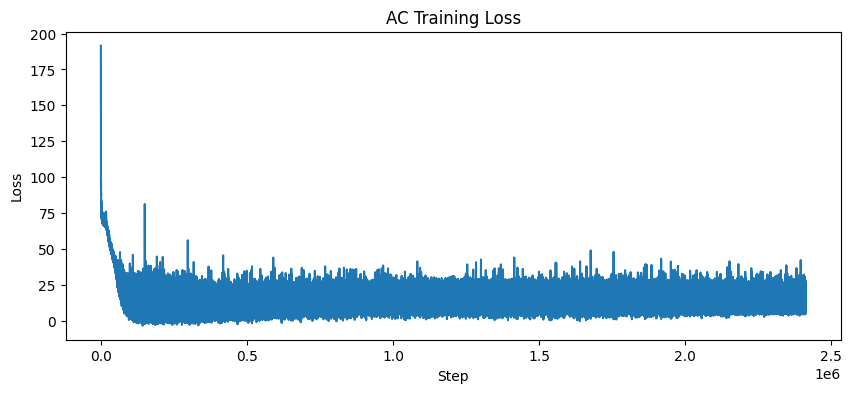

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('AC Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [17]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [ ]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'predictor_t',
    device=device)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, 
                                                model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, 
                                                use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 67 shards for split val
Decoder training: 3857920 samples, 120560 steps/epoch, 2411200 total steps
Decoder Step 0 | val loss: 0.8340
Decoder Step 0 | Loss: 0.86270
Decoder Step 100 | Loss: 0.82218
Decoder Step 200 | Loss: 0.71287
Decoder Step 300 | Loss: 0.62913
Decoder Step 400 | Loss: 1.29546
Decoder Step 500 | val loss: 0.5217
Decoder Step 500 | Loss: 0.43666
Decoder Step 600 | Loss: 0.50865
Decoder Step 700 | Loss: 0.92340
Decoder Step 800 | Loss: 0.43072
Decoder Step 900 | Loss: 0.80617
Decoder Step 1000 | val loss: 0.3769
Decoder Step 1000 | Loss: 0.34499
Decoder Step 1100 | Loss: 0.36326
Decoder Step 1200 | Loss: 0.32823
Decoder Step 1300 | Loss: 0.34981
Decoder Step 1400 | Loss: 0.77618
Decoder Step 1500 | val loss: 0.6

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Decoder Step 2124400 | Loss: 0.16706
Decoder Step 2124500 | val loss: 0.3616
Decoder Step 2124500 | Loss: 0.17546
Decoder Step 2124600 | Loss: 0.18768
Decoder Step 2124700 | Loss: 0.19322
Decoder Step 2124800 | Loss: 0.38054
Decoder Step 2124900 | Loss: 0.17436
Decoder Step 2125000 | val loss: 0.2828
Decoder Step 2125000 | Loss: 0.17572
Decoder Step 2125100 | Loss: 0.16281
Decoder Step 2125200 | Loss: 0.11663
Decoder Step 2125300 | Loss: 0.37102
Decoder Step 2125400 | Loss: 0.12547
Decoder Step 2125500 | val loss: 0.1746
Decoder Step 2125500 | Loss: 0.17646
Decoder Step 2125600 | Loss: 0.18004
Decoder Step 2125700 | Loss: 0.20162
Decoder Step 2125800 | Loss: 0.12237
Decoder Step 2125900 | Loss: 0.16601
Decoder Step 2126000 | val loss: 0.1650
Decoder Step 2126000 | Loss: 0.17841
Decoder Step 2126100 | Loss: 0.11543
Decoder Step 2126200 | Loss: 0.17408
Decoder Step 2126300 | Loss: 0.16501
Decoder Step 2126400 | Loss: 0.14071
Decoder Step 2126500 | val loss: 0.1694
Decoder Step 2126500 | 

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## AC Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': ac_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
eval_ctx._decoder = decoder
full_eval_results = run_ac_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(full_eval_results, data_cfg.eval_results_dir / 'ac_eval_report.json')
full_eval_results

In [ ]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [ ]:
print('=== Training Complete ===')
print(f'Encoder training final loss: {pt_results["final_loss"]:.5f}')
print(f'Composer training final loss: {align_results["final_loss"]:.5f}')
print(f'AC training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')